# How much does performance depend on the number of samples?


Looks like we should probably use 10 generations insteaed of just 5

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [2]:
# export to eval file
def get_vals(x):
    return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [3]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

Base runs are:

160140
160141

Use these to derive many more 'compute_uncertainty' runs that just take a subset of the generations!

In [4]:
len('5jpbzero')

8

In [56]:
# raise "there is probably a bug that affects these runs, where strict entailment got enabled for the repeated 'compute uncertainties run'!! also condition on question was no longer enabled!"
# --> actually it's all good! strict entailment was not the default back then! :)

In [54]:
wandbids = ['o161v4v5', 'l4gww8m1']
for slurmid in range(160229, 160240+1):
    wandbid = !grep "runs" log/*{slurmid}*
    if 'No such file' not in wandbid[0]:
        wandbids.append(wandbid[0][-8:])
    else:
        print(slurmid)

In [6]:
len(wandbids)

14

In [7]:
finished_runs = []
for wandbid in wandbids:
    run = api.run(f'goatml/semantic_uncertainty/{wandbid}')
    if run.state == 'finished':
        finished_runs.append(wandbid)
    else:
        print(wandbid, run.state)

In [8]:
len(finished_runs)

14

In [28]:
# The new runs are doing strict entailment _and_ condition on question,

all_configs, all_results = {}, {}

runs = {}
for wandb_id in finished_runs:
    
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)

    num_gen = all_configs[wandb_id].get('use_num_generations', dict(value=15))['value']
    dataset = all_configs[wandb_id]['dataset']['value']

    print(wandb_id, f'{dataset}-{num_gen}')
    runs[wandb_id] = f'{dataset}-{num_gen}'


o161v4v5 bioasq-15
l4gww8m1 trivia_qa-15
5jpbzero bioasq-12
1gfqh1i3 bioasq-10
bj1wzokx bioasq-8
fuwikbwo bioasq-6
uwwk242i bioasq-4
oybbluox bioasq-2
v2e6pkks trivia_qa-12
sy2g4uyv trivia_qa-10
l8yz9qnt trivia_qa-8
sw9a3hjv trivia_qa-6
4cdg8npu trivia_qa-4
x2qq28cw trivia_qa-2


In [ ]:
sy2g4uyv

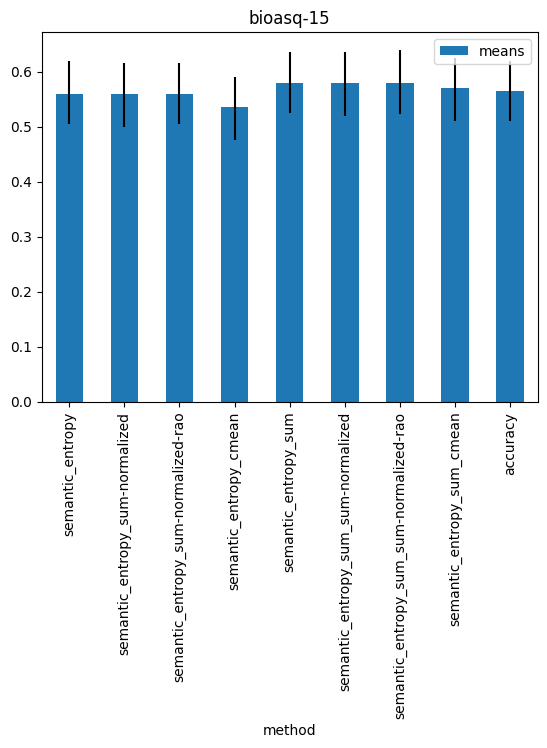

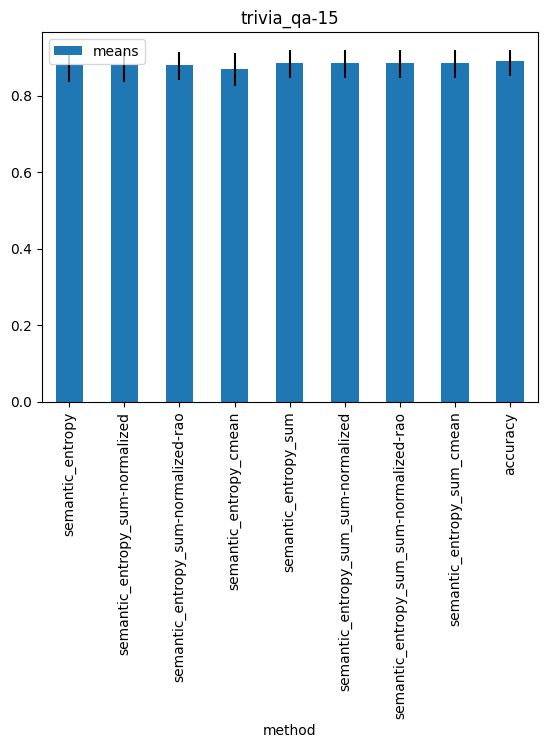

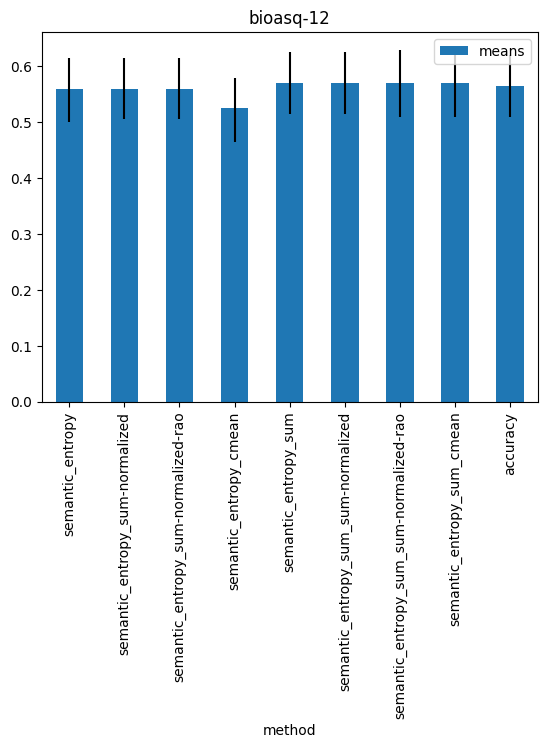

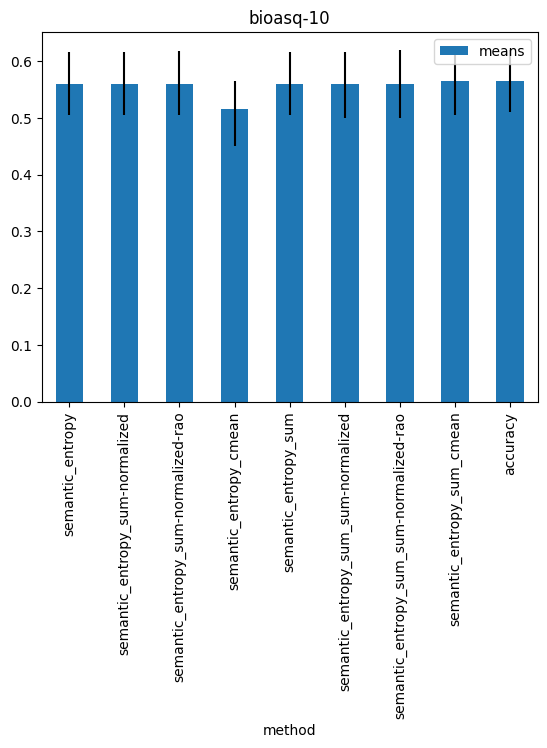

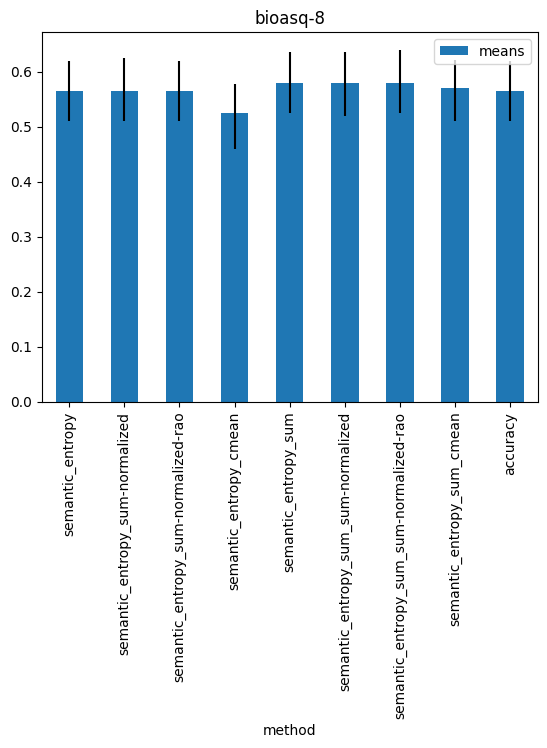

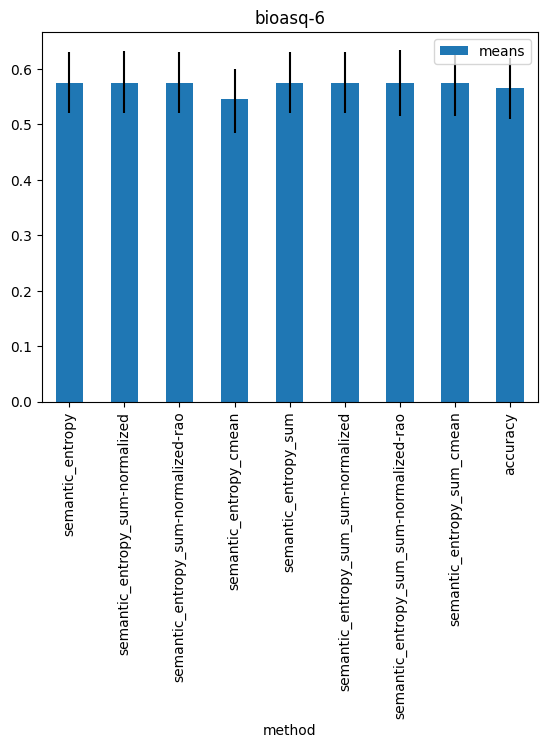

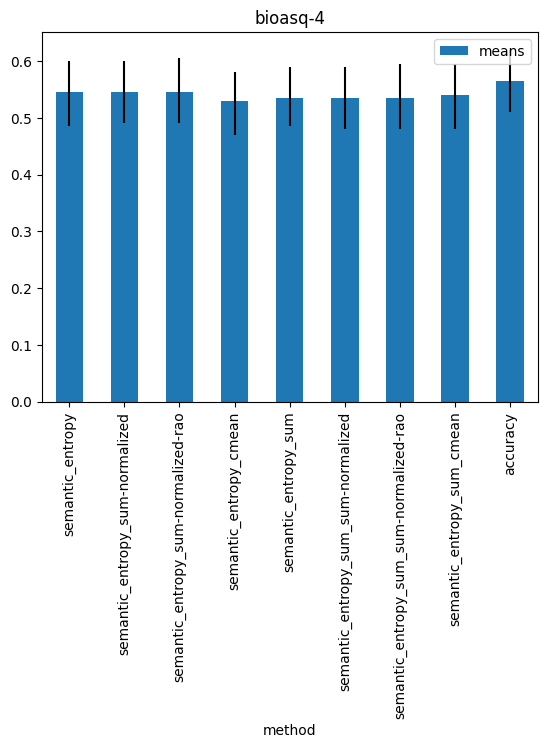

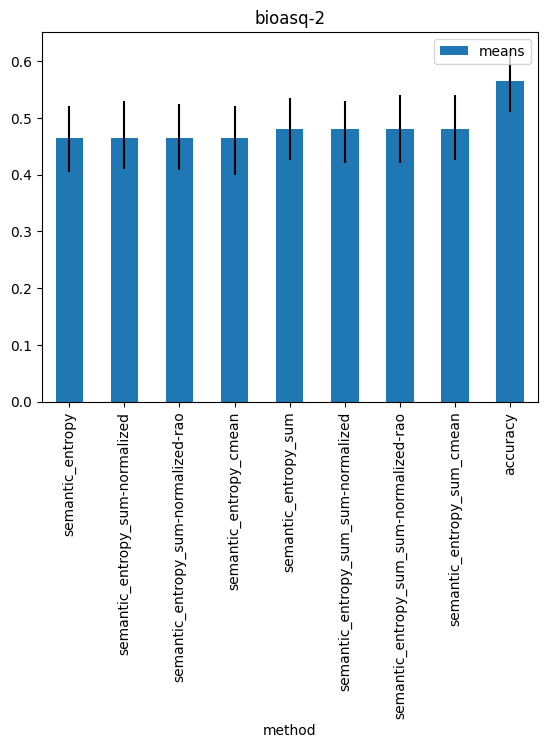

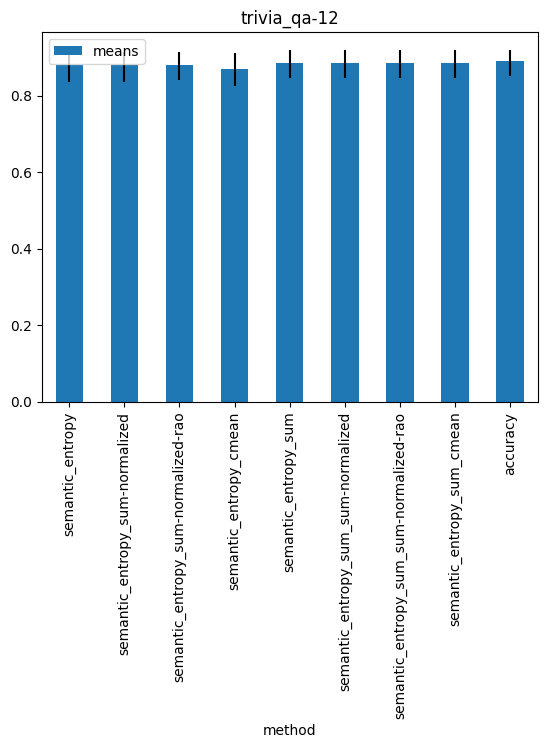

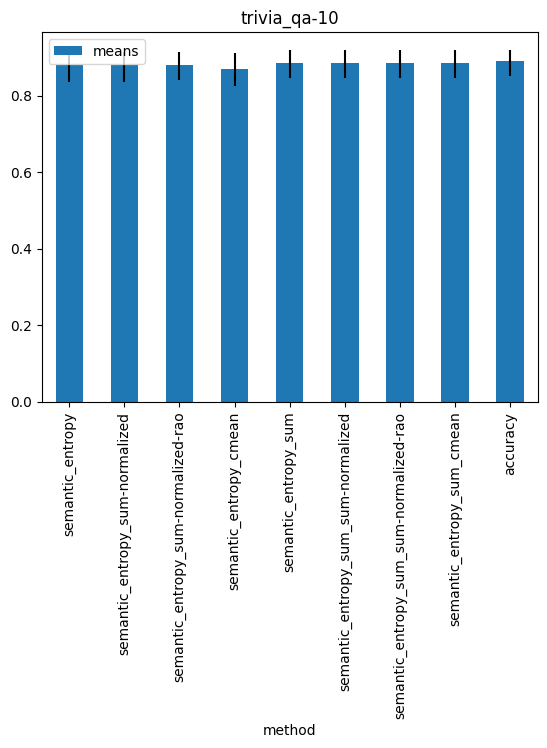

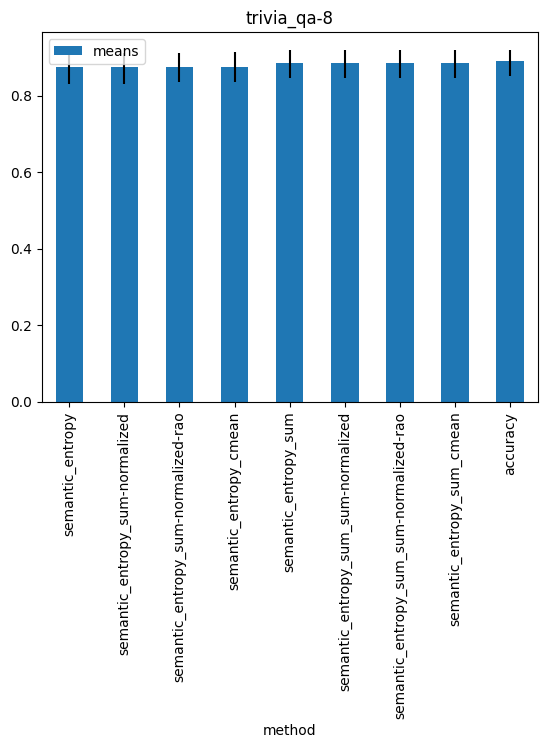

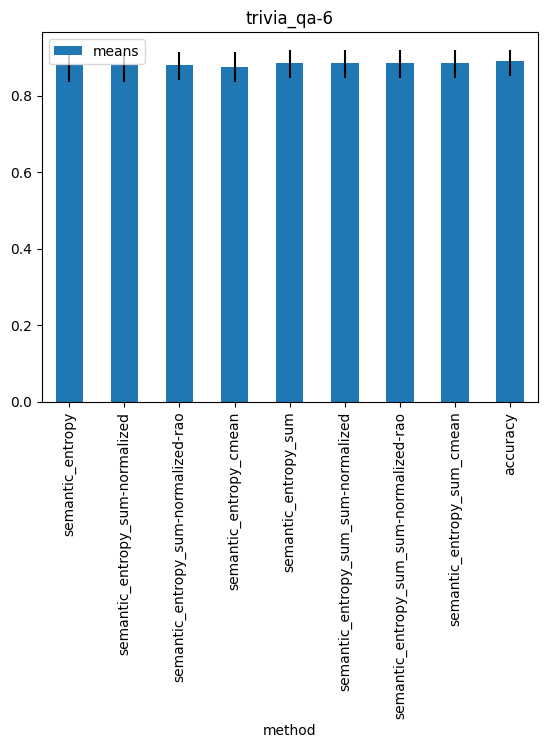

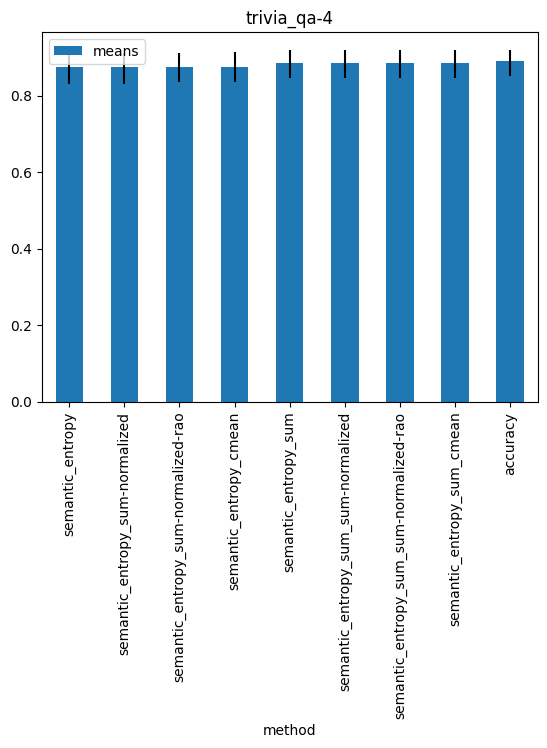

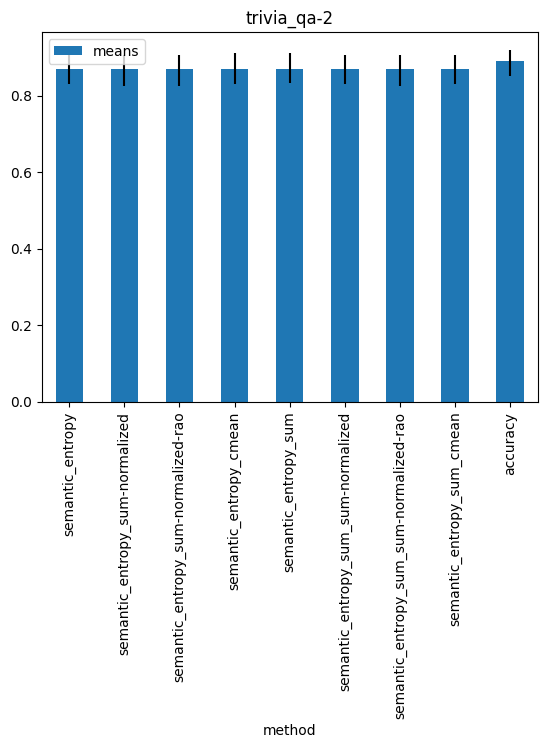

In [10]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)


It seems like we do not significantly improve accuracy doing this. 

If anything, we should probably just trust the low-temperature generation.

In [29]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

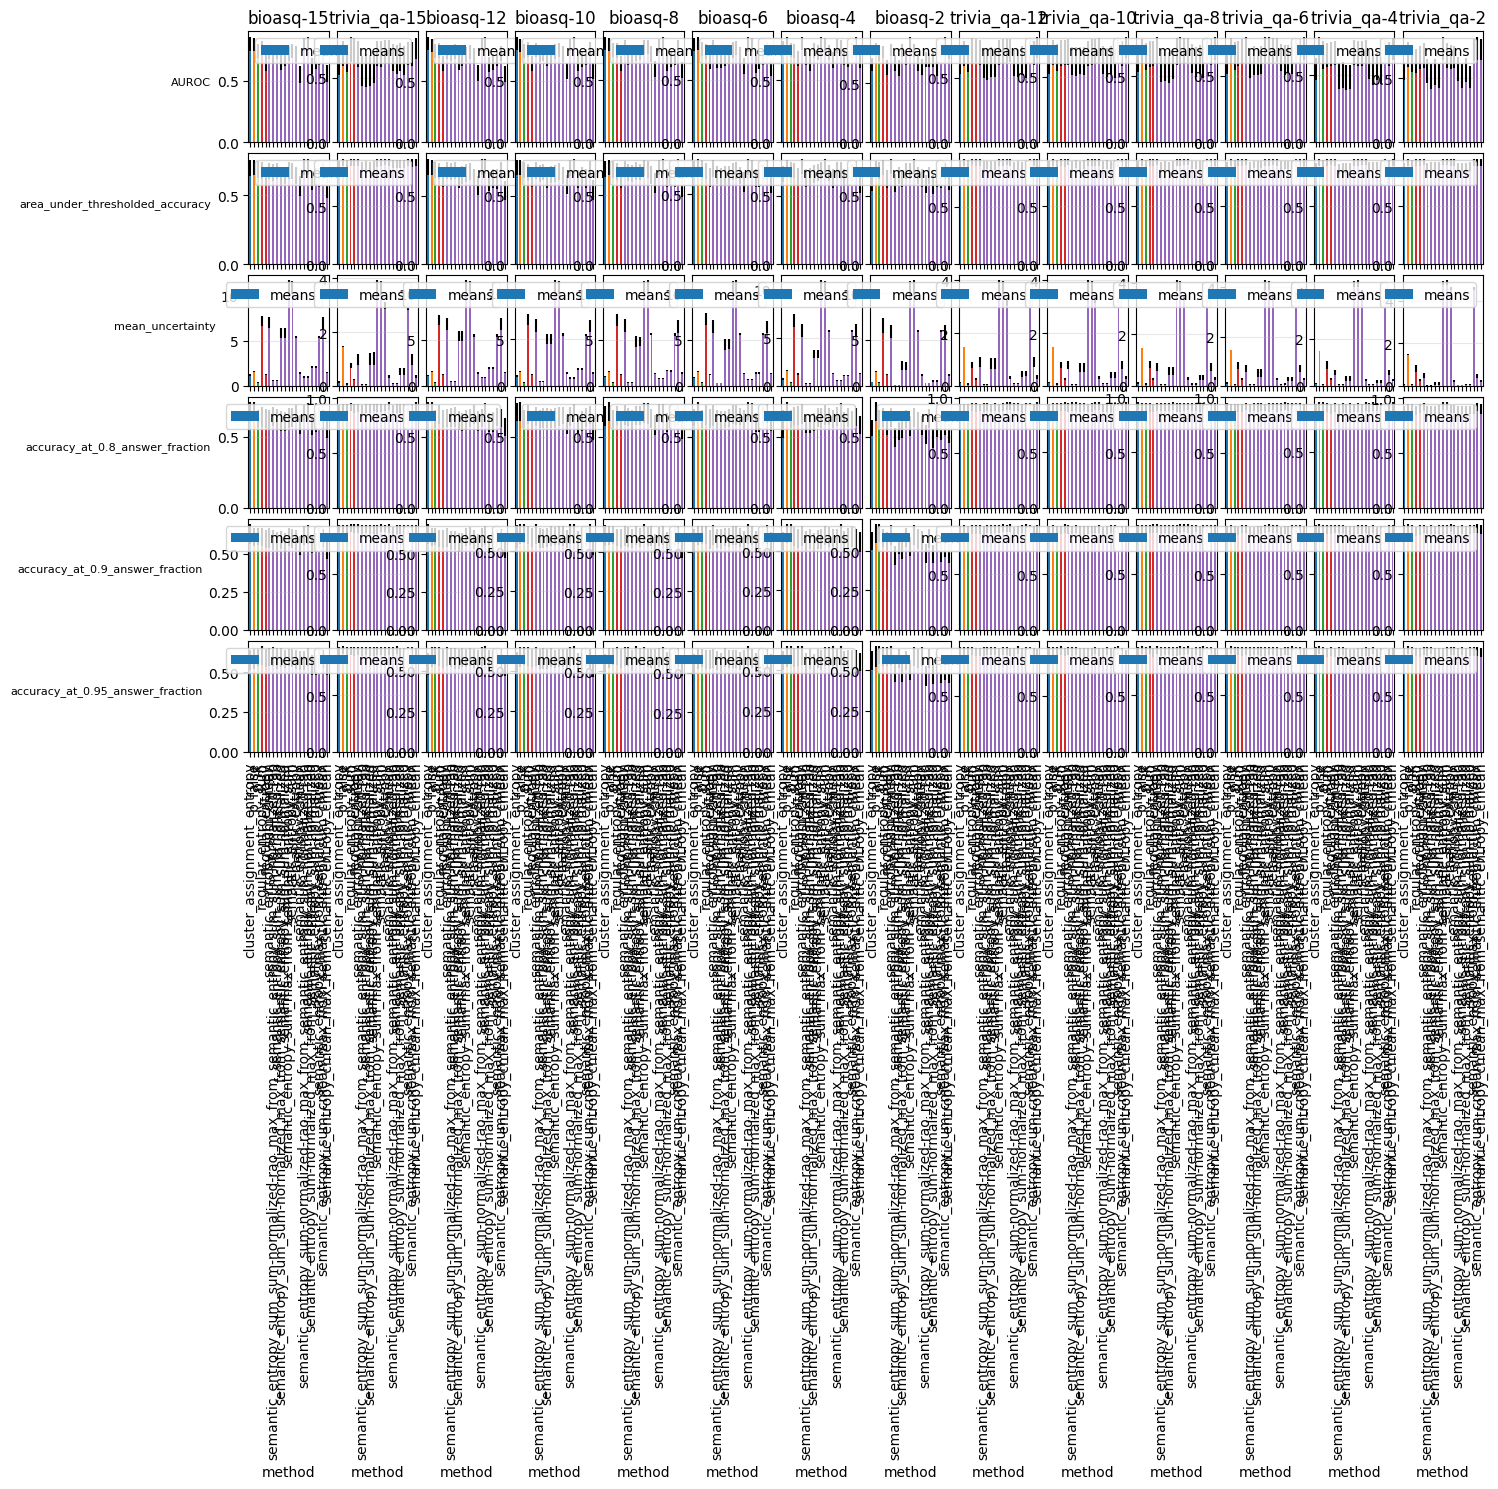

In [12]:
fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

    for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
        plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

        if i == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

        if k == 0:
            ax.set_title(runs[wandb_id])


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [31]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

all_runs['n_generation'] = all_runs.run.map(lambda x: int(x.split('-')[1]))
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[0])

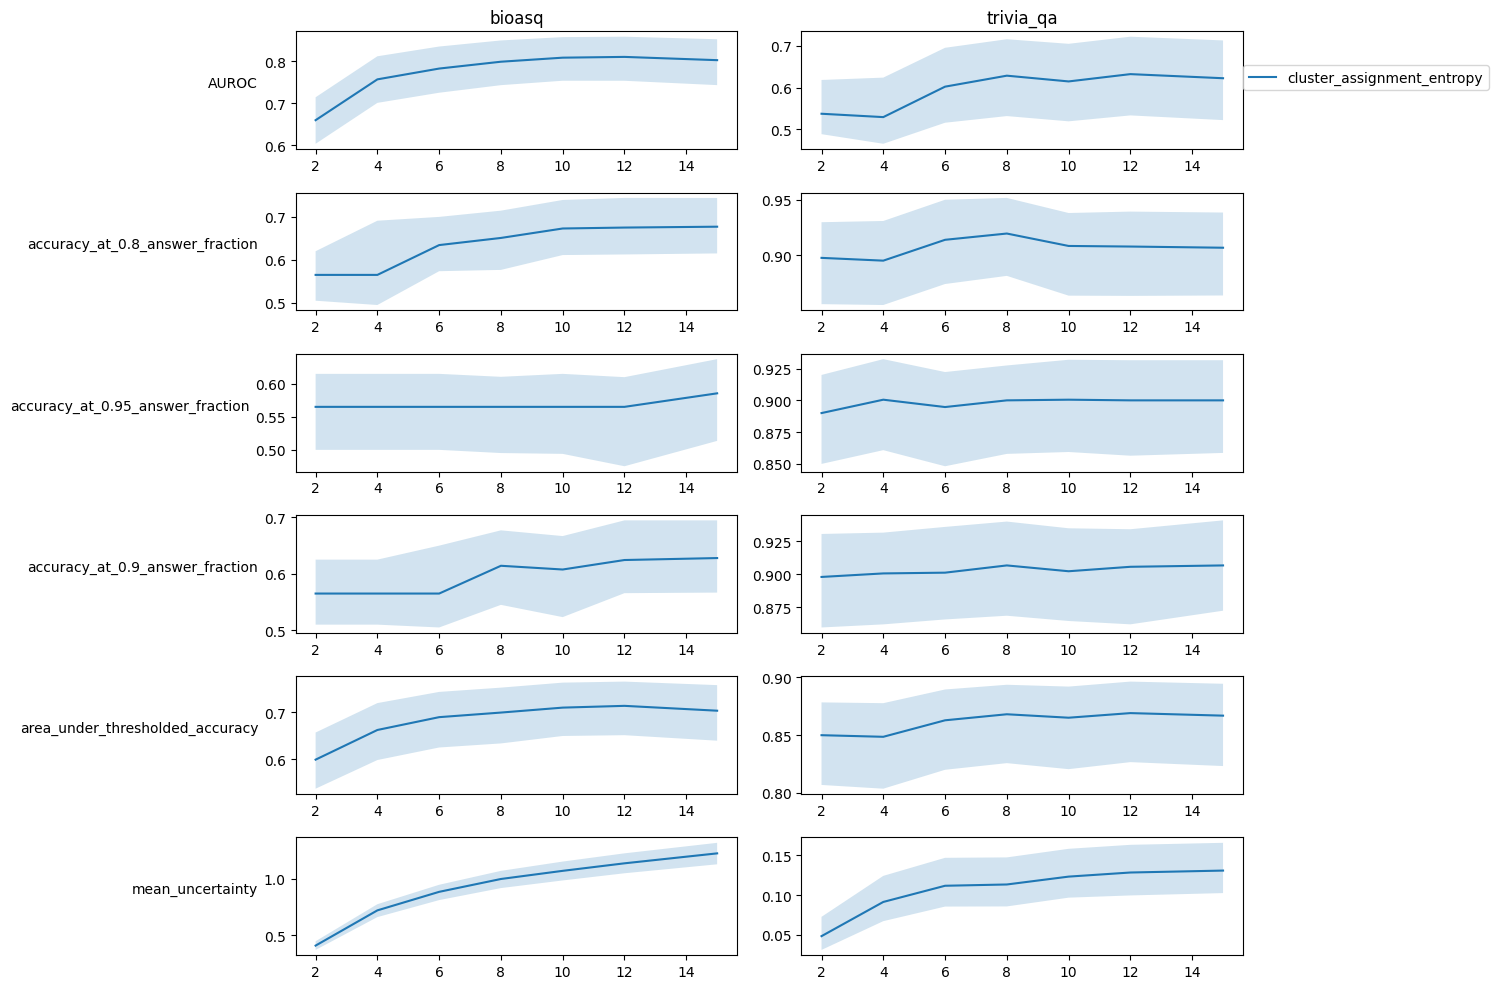

In [15]:
df2 = deepcopy(all_runs)

fig, axes_2d = plt.subplots(df2.metric.nunique(), df2.dataset.nunique(), figsize=(15, 10))


methods = ['cluster_assignment_entropy']

for method in methods:
    df3 = df2[all_runs.method == method]
    for i, (axes, (metric, gdf)) in enumerate(zip(axes_2d, df3.groupby('metric'))):
        axes[0].set_ylabel(metric, rotation=0, ha='right')
        for ax, (dataset, ggdf) in zip(axes, gdf.groupby('dataset')):
            if i == 0:
                ax.set_title(dataset)
        
            ax.plot(ggdf.n_generation, ggdf.means, label=method)
            ax.fill_between(ggdf.n_generation, ggdf.low, ggdf.high, alpha=0.2, zorder=-10)

axes_2d[0][1].legend(loc=(1, 0.5))
plt.tight_layout()

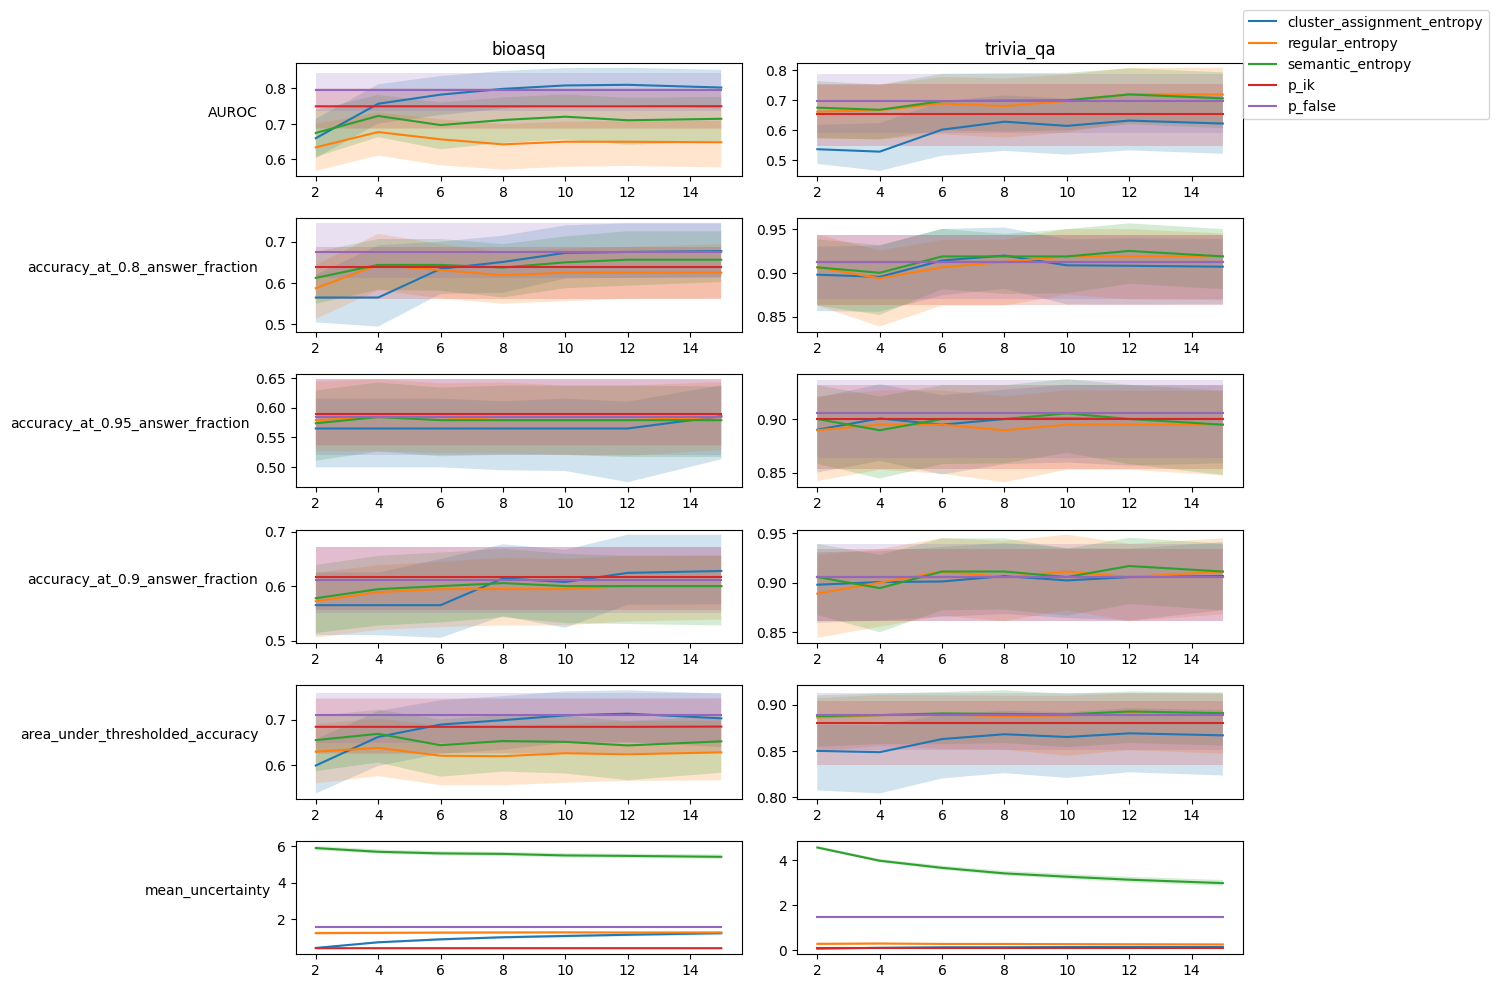

In [16]:
df2 = deepcopy(all_runs)

fig, axes_2d = plt.subplots(df2.metric.nunique(), df2.dataset.nunique(), figsize=(15, 10))


main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false',]
methods = main_methods

for method in methods:
    df3 = df2[all_runs.method == method]
    for i, (axes, (metric, gdf)) in enumerate(zip(axes_2d, df3.groupby('metric'))):
        axes[0].set_ylabel(metric, rotation=0, ha='right')
        for ax, (dataset, ggdf) in zip(axes, gdf.groupby('dataset')):
            if i == 0:
                ax.set_title(dataset)
        
            ax.plot(ggdf.n_generation, ggdf.means, label=method)
            ax.fill_between(ggdf.n_generation, ggdf.low, ggdf.high, alpha=0.2, zorder=-10)

axes_2d[0][1].legend(loc=(1, 0.5))
plt.tight_layout()

**p_false should improve with more samples --> it just doesnt here because I am only adding samples via compute_uncertaity and p_false is already completely done in generate --> wait, but this means p_false is at 15 samples here!**




And I have p_false for 5 generations from a previous run!

In [47]:
base_runs = {
    '4ug9fcne': 'bioasq-5',
    'o161v4v5': 'bioasq-15',
    '0j29p31i': 'trivia_qa-5',
    'l4gww8m1': 'trivia_qa-15',
}
for wandb_id in base_runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [48]:
pdfs = {}
for wandb_id in base_runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

runids = list(pdfs.keys())
tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = base_runs[runids[0]]
for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = base_runs[runid]
    tmp = pd.concat([tmp, tmp2])
all_base_runs = tmp.reset_index()

all_base_runs['n_generation'] = all_base_runs.run.map(lambda x: int(x.split('-')[1]))
all_base_runs['dataset'] = all_base_runs.run.map(lambda x: x.split('-')[0])

/tmp/ipykernel_1672490/3356713905.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.method.map(lambda x: x in main_methods)]
/tmp/ipykernel_1672490/3356713905.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1672490/3356713905.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


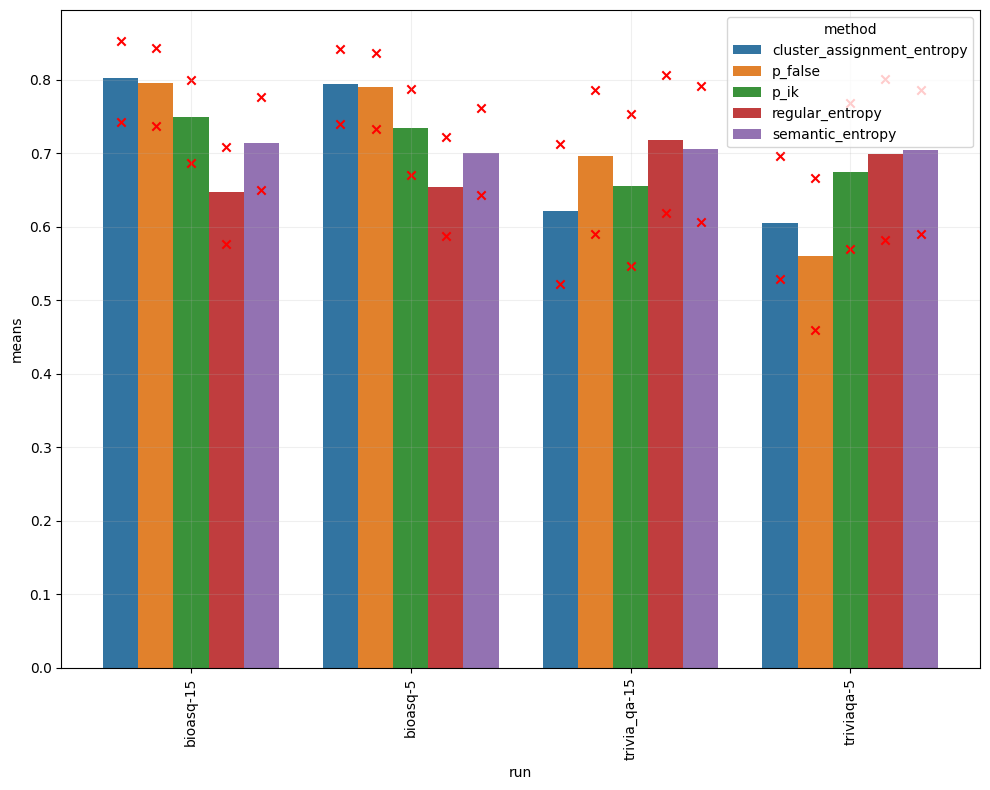

In [21]:
df2 = deepcopy(all_base_runs)
df2 = df2[df2.metric == 'AUROC']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_1672490/351723859.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.method.map(lambda x: x in main_methods)]
/tmp/ipykernel_1672490/351723859.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1672490/351723859.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


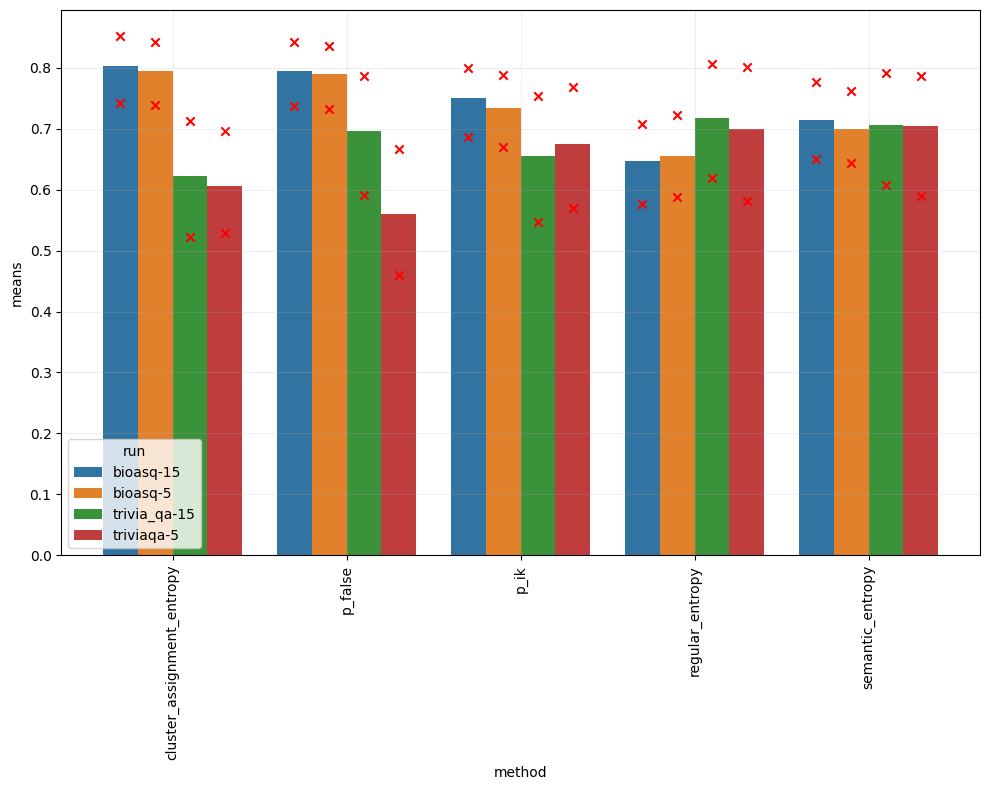

In [22]:
df2 = deepcopy(all_base_runs)
df2 = df2[df2.metric == 'AUROC']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2.sort_values(['run', 'method'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="method",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [33]:
all_base_runs.set_index('method').loc[method]

NameError: name 'all_base_runs' is not defined

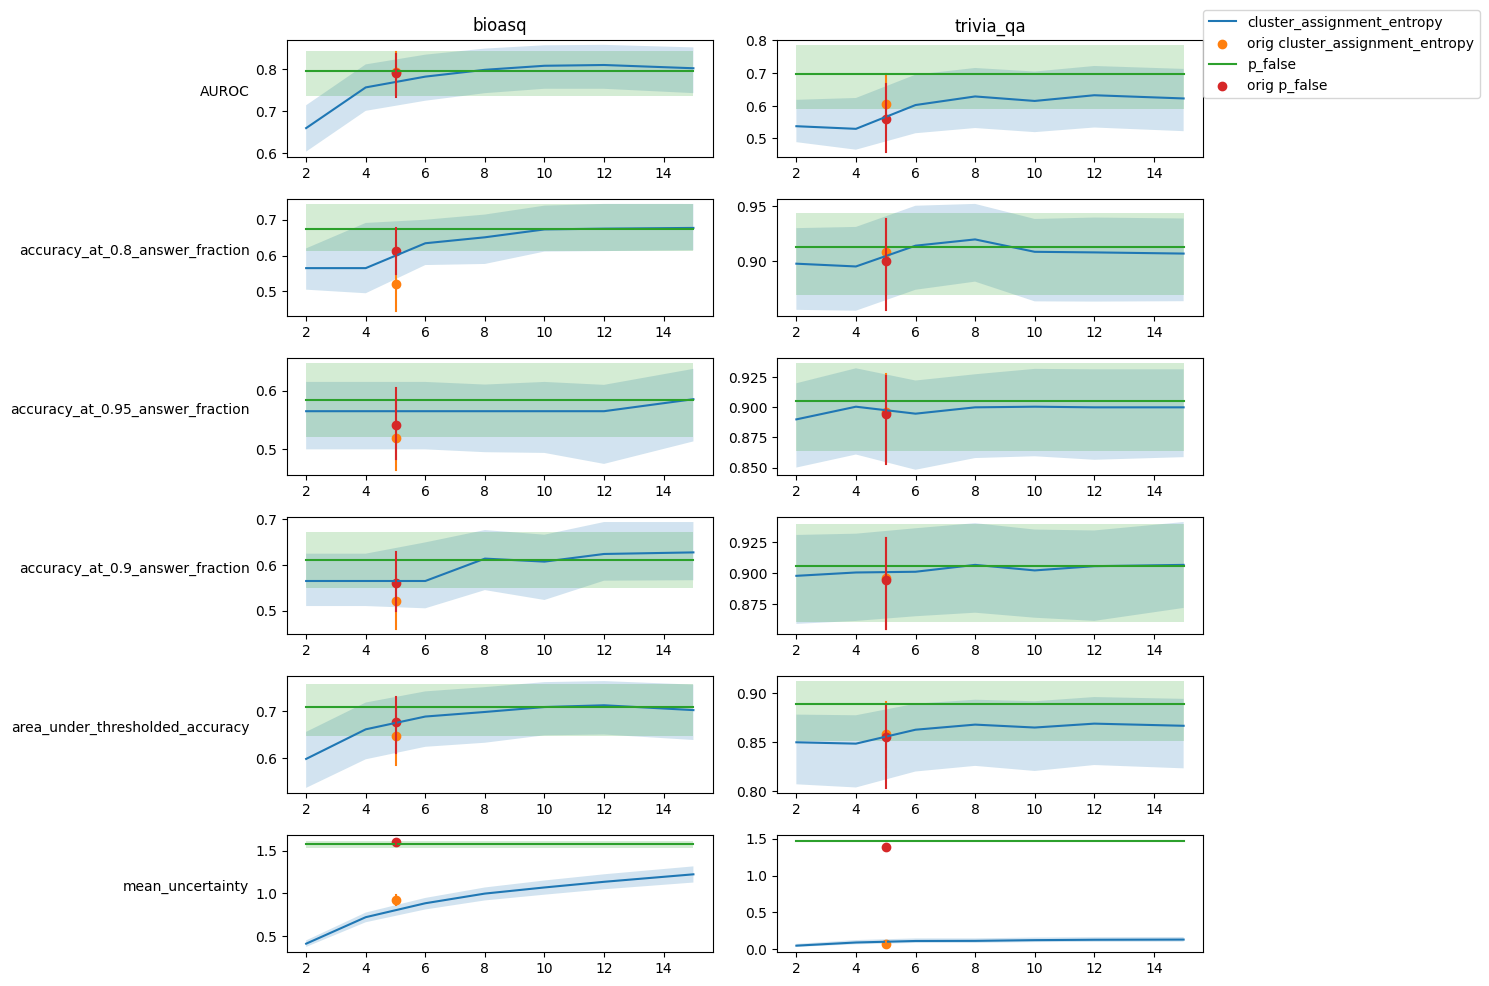

In [53]:
df2 = deepcopy(all_runs)

fig, axes_2d = plt.subplots(df2.metric.nunique(), df2.dataset.nunique(), figsize=(15, 10))

main_methods = ['cluster_assignment_entropy', 'p_false',]
methods = main_methods

for method in methods:
    df3 = df2[all_runs.method == method]
    for i, (axes, (metric, gdf)) in enumerate(zip(axes_2d, df3.groupby('metric'))):
        axes[0].set_ylabel(metric, rotation=0, ha='right')
        for ax, (dataset, ggdf) in zip(axes, gdf.groupby('dataset')):
            if i == 0:
                ax.set_title(dataset)
            ax.plot(ggdf.n_generation, ggdf.means, label=method)
            ax.fill_between(ggdf.n_generation, ggdf.low, ggdf.high, alpha=0.2, zorder=-10)

            # previous 5 generation results
            base = all_base_runs.set_index('method').loc[method]\
                .set_index('metric').loc[metric]\
                .set_index('dataset').loc[dataset]\
                .set_index('n_generation').loc[5]

            ax.scatter([5], [base.means], label=f'orig {method}')
            ax.plot(2*[5], [base.low, base.high])

axes_2d[0][1].legend(loc=(1, 0.5))
plt.tight_layout()

Note p_false line is always at 15!!!